#  <span style="color:red">ASMAE AIT OUALI</span>


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model    import LinearRegression
# On lit le fichier CSV contenant les données publicitaires
# Ce dataset contient généralement les dépenses en publicité (TV, radio, journal)
# et les ventes associées.
df = pd.read_csv("advertising.csv")
# Afficher les 10 premières lignes pour comprendre la structure des données
# Cela permet de vérifier que les colonnes sont bien chargées
print(df.head())
print(f"\nShape    : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print("\nStatistiques descriptives :")
print(df.describe())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Shape    : (200, 4)
Colonnes : ['TV', 'Radio', 'Newspaper', 'Sales']

Statistiques descriptives :
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


#  <span style="color:blue">Régression linéaire </span>


In [22]:
#  Régression Linéaire SIMPLE avec sklearn
#  Dataset : Advertising
#  X = TV  →  y = Sales

from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_squared_error


#  Définir X et y
X = df[["TV"]]     
y = df["Sales"]

#  Split Train / Test (80% / 20%) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain : {len(X_train)} exemples | Test : {len(X_test)} exemples")

#  Créer et entraîner le modèle 
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\n Paramètres appris ")
print(f"Intercept  b0 = {model.intercept_:.4f}")
print(f"Pente      b1 = {model.coef_[0]:.4f}")
print(f"\nÉquation : Sales = {model.intercept_:.2f} + {model.coef_[0]:.2f} * TV")

#  Prédictions 
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print(f"{'Métrique':<10} {'Train':>10} {'Test':>10}")
print("-" * 32)
print(f"{'MSE':<10} {mean_squared_error(y_train, y_pred_train):>10.4f} {mean_squared_error(y_test, y_pred_test):>10.4f}")




Train : 160 exemples | Test : 40 exemples

 Paramètres appris 
Intercept  b0 = 7.0071
Pente      b1 = 0.0555

Équation : Sales = 7.01 + 0.06 * TV
Métrique        Train       Test
--------------------------------
MSE            4.9984     6.1011


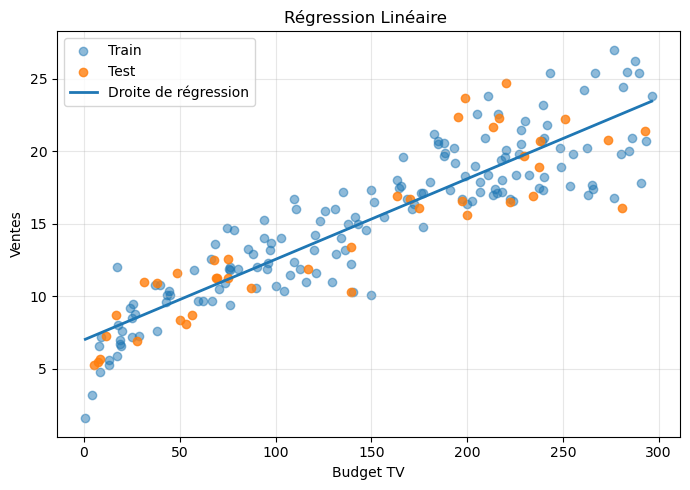

In [23]:
# ── 7. Visualisation ────────────────────────────

# Générer une ligne continue AVEC nom de colonne
x_line = pd.DataFrame(
    np.linspace(X["TV"].min(), X["TV"].max(), 300),
    columns=["TV"]
)

# Prédictions
y_line = model.predict(x_line)

plt.figure(figsize=(7, 5))

# Train
plt.scatter(X_train, y_train, alpha=0.5, label="Train")

# Test
plt.scatter(X_test, y_test, alpha=0.8, label="Test")

# Droite
plt.plot(x_line, y_line, linewidth=2, label="Droite de régression")

# Labels
plt.xlabel("Budget TV")
plt.ylabel("Ventes")

# Titre
plt.title(f"Régression Linéaire ")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  <span style="color:blue">Régression multiple </span>


In [24]:
# TP — Régression Linéaire MULTIPLE avec sklearn
#  Dataset : Advertising
#  X = [TV, Radio, Newspaper]  →  y = Sales


# Définir X et y 
# X = variables explicatives (entrées du modèle)
# TV : budget TV
# Radio : budget radio
# Newspaper : budget journaux
X = df[["TV", "Radio", "Newspaper"]]
# y = variable cible (ce qu’on veut prédire)
y = df["Sales"]

# ── 3. Split Train / Test (80% / 20%) ───────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain : {len(X_train)} exemples , Test : {len(X_test)} exemples")


Train : 160 exemples , Test : 40 exemples


In [25]:
#Créer et entraîner le modèle 

# On utilise une régression linéaire classique
# Elle cherche une relation :
#
# Sales = b0 + b1*TV + b2*Radio + b3*Newspaper

model = LinearRegression()
# Entraînement du modèle

model.fit(X_train, y_train)
# b0 = intercept (valeur de base)
# b1, b2, b3 = impact de chaque variable

print(f"\n=== Coefficients appris ===")
print(f"Intercept b0       = {model.intercept_:.4f}")
# Affichage automatique des coefficients

for nom, coef in zip(X.columns, model.coef_):
    print(f"Coef ({nom:<10}) = {coef:.4f}")

print(f"\nÉquation : Sales = {model.intercept_:.2f}"
      f" + {model.coef_[0]:.2f}·TV"
      f" + {model.coef_[1]:.2f}·Radio"
      f" + {model.coef_[2]:.2f}·Newspaper")

#  Prédictions

# y_pred_train → prédictions sur données d’entraînement
# y_pred_test  → prédictions sur données de test
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print(f"\n=== Évaluation du modèle ===")
print(f"{'Métrique':<10} {'Train':>10} {'Test':>10}")
print("-" * 32)
print(f"{'MSE':<10} {mean_squared_error(y_train, y_pred_train):>10.4f} {mean_squared_error(y_test, y_pred_test):>10.4f}")



=== Coefficients appris ===
Intercept b0       = 4.7141
Coef (TV        ) = 0.0545
Coef (Radio     ) = 0.1009
Coef (Newspaper ) = 0.0043

Équation : Sales = 4.71 + 0.05·TV + 0.10·Radio + 0.00·Newspaper

=== Évaluation du modèle ===
Métrique        Train       Test
--------------------------------
MSE            2.6761     2.9078


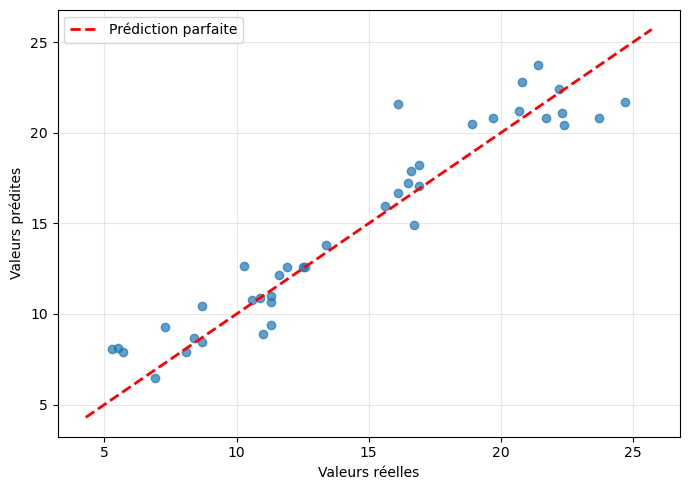

In [26]:

# Visualisation 

plt.figure(figsize=(7, 5))

#Réel vs Prédit (TEST)

# Scatter plot : valeurs réelles vs prédictions
plt.scatter(y_test, y_pred_test, alpha=0.7)

# Ligne idéale (y = x)
lims = [
    min(y_test.min(), y_pred_test.min()) - 1,
    max(y_test.max(), y_pred_test.max()) + 1
]
plt.plot(lims, lims, "r--", linewidth=2, label="Prédiction parfaite")

# Labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")


# Légende + grille
plt.legend()
plt.grid(alpha=0.3)

# Ajustement
plt.tight_layout()
# Affichage
plt.show()

#  <span style="color:blue">Régression polynomiale </span>


In [27]:
#  Régression POLYNOMIALE avec sklearn
#  Dataset : Advertising
#  X = TV  →  y = Sales
from sklearn.preprocessing import PolynomialFeatures

X = df[["TV"]]        # shape (200, 1)
y = df["Sales"]

# ── 2. Split Train / Test (80% / 20%) ───────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# ── 3. Transformer les features (degré 2) ───────
#
#   PolynomialFeatures(degree=2) crée :
#   [ 1,  TV,  TV² ]
# ── PARAMÈTRE ──
DEGRE = 2

# ── Features polynomiales ──
poly = PolynomialFeatures(degree=DEGRE)

X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# Modèle
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Prédiction 
y_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)

print("MSE =", round(mse, 4))

# Courbe lisse 
x_line = pd.DataFrame(
    np.linspace(X["TV"].min(), X["TV"].max(), 300),
    columns=["TV"]
)

x_line_poly = poly.transform(x_line)
y_line = model.predict(x_line_poly)



MSE = 5.6829


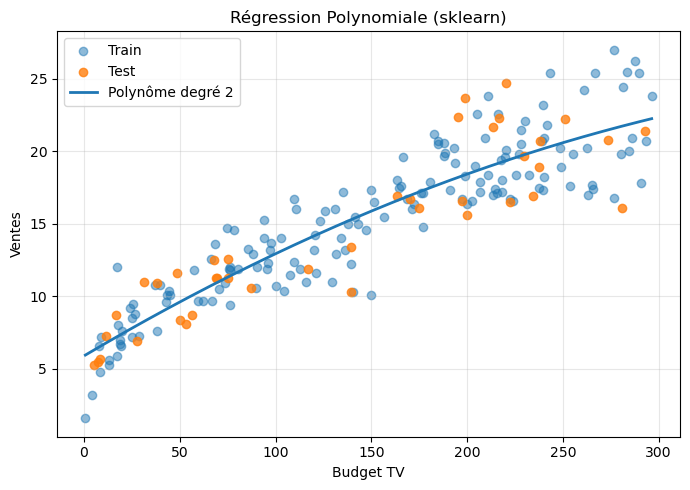

In [28]:
# ── Visualisation ──
plt.figure(figsize=(7, 5))

plt.scatter(X_train, y_train, alpha=0.5, label="Train")
plt.scatter(X_test, y_test, alpha=0.8, label="Test")

plt.plot(x_line, y_line, linewidth=2,
         label=f"Polynôme degré {DEGRE}")

plt.xlabel("Budget TV")
plt.ylabel("Ventes")
plt.title("Régression Polynomiale (sklearn)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  <span style="color:blue">Logistic Regression</span>


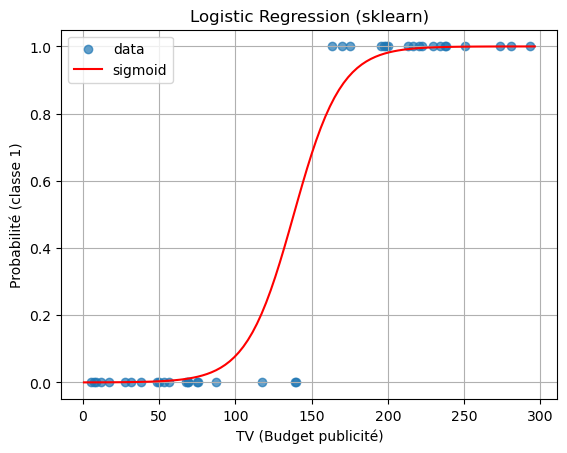

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Définition des variables
# X : variable explicative (Budget TV)
# IMPORTANT : double crochet → format DataFrame (obligatoire pour sklearn)
X = df[["TV"]]

# y : variable cible transformée en classification
#   1 → ventes élevées (Sales > 15)
#   0 → ventes faibles
y = (df["Sales"] > 15).astype(int)

# Split Train / Test

# On sépare les données :
# 80% pour l'entraînement
# 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Création et entraînement du modèle

# LogisticRegression :
# modèle de classification basé sur la fonction sigmoid
model = LogisticRegression()

# Apprentissage :
# le modèle va trouver les meilleurs paramètres
# pour séparer les classes (0 et 1)
model.fit(X_train, y_train)

#Prédictions

# Prédiction des classes (0 ou 1)
y_pred = model.predict(X_test)

# Calcul de l'accuracy :
# proportion de bonnes prédictions
#Visualisation
# Chaque point = une observation
# Axe X = TV
# Axe Y = classe (0 ou 1)
plt.scatter(X_test, y_test, alpha=0.7, label="data")

# Courbe sigmoid 

# On crée une ligne continue de valeurs TV
x_line = np.linspace(X["TV"].min(), X["TV"].max(), 100)

# IMPORTANT :
# transformer en DataFrame pour éviter warning sklearn
x_line = pd.DataFrame(x_line, columns=["TV"])   

# predict_proba :
# retourne les probabilités [classe 0, classe 1]
# [:,1] → probabilité d'appartenir à la classe 1
y_line = model.predict_proba(x_line)[:, 1]

# tracer la courbe sigmoid
plt.plot(x_line, y_line, color="red", label="sigmoid")

# Mise en forme du graphique
plt.xlabel("TV (Budget publicité)")
plt.ylabel("Probabilité (classe 1)")
plt.title("Logistic Regression (sklearn)")
plt.legend()
plt.grid()

# affichage final
plt.show()